# Multi-Model Serving Infrastructure (NVIDIA Triton Inference Server)

## Introduction

Lessons 04-08 optimized serving a single LLM as fast as possible. Real production platforms rarely serve just one model — they serve dozens of models (different sizes, different tasks, different teams) on a shared GPU fleet. This lesson covers NVIDIA Triton Inference Server, the standard framework for **multi-model, multi-framework serving**, and the GPU-sharing mechanics (dynamic batching, concurrent model execution, model instance groups) that make shared-fleet serving efficient rather than wasteful.

## Theory

### The multi-tenancy problem

Given $K$ models with request rates $\{\lambda_1, \dots, \lambda_K\}$ and a fixed pool of $G$ GPUs, the naive allocation — one dedicated GPU per model — wastes capacity whenever any model's request rate doesn't saturate its dedicated GPU:

$$
\text{Utilization}_{dedicated} = \frac{1}{G}\sum_{k=1}^{K} \frac{\lambda_k \cdot t_k}{\text{GPU capacity}_k}
$$

For a typical enterprise deployment with a long tail of low-traffic models, this can leave most GPUs mostly idle most of the time. Triton's model is **shared infrastructure with per-model resource policies**, analogous to Section 23's Kubernetes resource-sharing model but applied to inference serving specifically.

### Dynamic batching (server-side request coalescing)

Unlike vLLM's continuous batching (Lesson 07), which is specific to autoregressive generation, Triton's dynamic batcher is a general mechanism: incoming requests to the same model within a short window $\delta$ (configurable, e.g. 5ms) are coalesced into a single batched inference call:

$$
\text{Effective batch size} \approx \lambda \cdot \delta
$$

trading a small added latency ($\le \delta$) for throughput gains from better GPU utilization — the batching-window/latency tradeoff is a direct knob exposed in Triton's per-model config, distinct per model based on its own SLA.

### Concurrent model execution & instance groups

Triton can run **multiple instances** of the same model (or multiple different models) concurrently on one GPU using CUDA streams, when a single instance doesn't saturate the GPU's compute:

$$
\text{Throughput}_{total} \approx \min\left(N_{instances} \times \text{Throughput}_{single}, \ \text{GPU peak throughput}\right)
$$

The ceiling is reached when concurrent instances start contending for the same SM/memory-bandwidth resources — beyond that point, adding instances just adds queuing/context-switch overhead without net throughput gain, so instance-group sizing has an empirically-tuned optimum, not "more is always better."

### Ensemble and business-logic-scripting pipelines

Real inference requests often chain multiple models (e.g. tokenize → embed → retrieve → rerank → generate). Triton's **ensemble scheduler** expresses this as a DAG of model steps executed server-side, avoiding the network round-trip latency of client-orchestrated multi-model calls:

$$
\text{Latency}_{ensemble} = \sum_{\text{DAG path}} \text{Latency}_{step} \quad \text{(server-local, no per-step network hop)}
$$
$$
\text{Latency}_{client-orchestrated} = \sum_{\text{DAG path}} \left(\text{Latency}_{step} + \text{RTT}_{network}\right)
$$

For a 5-step pipeline with even modest network RTT (say 5ms), client orchestration adds 25ms of pure overhead the ensemble scheduler eliminates entirely — often the single biggest latency win in a multi-model RAG-style pipeline.

## Setup

`tritonclient`/a running Triton server aren't available in this sandbox; we simulate the GPU-sharing scheduling math directly — dynamic batching windows, instance-group throughput scaling, and ensemble-vs-client-orchestrated latency — using a discrete-event model that captures Triton's core resource-allocation tradeoffs.

In [1]:
# Simulated multi-model GPU-sharing scheduler — no live Triton server needed to reason about the tradeoffs.
import numpy as np

np.random.seed(23)
print("[INIT] Multi-model serving: dedicated GPUs vs. Triton shared-fleet simulation")

models = {
    "sentiment-classifier": {"lambda_rps": 40, "single_infer_ms": 3, "peak_rps_per_gpu": 1200},
    "image-embedder":       {"lambda_rps": 15, "single_infer_ms": 8, "peak_rps_per_gpu": 500},
    "reranker":             {"lambda_rps": 8,  "single_infer_ms": 12, "peak_rps_per_gpu": 300},
    "small-llm-7b":         {"lambda_rps": 25, "single_infer_ms": 40, "peak_rps_per_gpu": 90},
}

dedicated_gpus_needed = sum(int(np.ceil(m["lambda_rps"] / m["peak_rps_per_gpu"])) for m in models.values())
dedicated_utilization = {name: m["lambda_rps"] / m["peak_rps_per_gpu"] for name, m in models.items()}

print(f"[RESULT] Dedicated-GPU-per-model deployment requires: {dedicated_gpus_needed} GPUs")
for name, u in dedicated_utilization.items():
    print(f"         {name:22s} utilization on its dedicated GPU: {u:.1%}")

total_demand_share = sum(m["lambda_rps"] / m["peak_rps_per_gpu"] for m in models.values())
shared_gpus_needed = int(np.ceil(total_demand_share))
print(f"\n[RESULT] Triton shared-fleet (packing by capacity share): {shared_gpus_needed} GPUs "
      f"(vs. {dedicated_gpus_needed} dedicated) -> {dedicated_gpus_needed - shared_gpus_needed} GPUs saved")

[INIT] Multi-model serving: dedicated GPUs vs. Triton shared-fleet simulation
[RESULT] Dedicated-GPU-per-model deployment requires: 4 GPUs
         sentiment-classifier   utilization on its dedicated GPU: 3.3%
         image-embedder         utilization on its dedicated GPU: 3.0%
         reranker               utilization on its dedicated GPU: 2.7%
         small-llm-7b           utilization on its dedicated GPU: 27.8%

[RESULT] Triton shared-fleet (packing by capacity share): 1 GPUs (vs. 4 dedicated) -> 3 GPUs saved


## Telemetry & Audit

Compute the dynamic-batching throughput/latency tradeoff and the ensemble-vs-client-orchestration latency gap for a representative RAG-style pipeline — the two decisions a Triton deployment config actually encodes.

In [2]:
import pandas as pd

def dynamic_batch_effective_size(lambda_rps, window_ms):
    return lambda_rps * (window_ms / 1000)

rows = []
for window_ms in [1, 5, 10, 25]:
    eff_batch = dynamic_batch_effective_size(models["small-llm-7b"]["lambda_rps"], window_ms)
    rows.append((window_ms, eff_batch, window_ms))  # added latency == window (worst case: request arrives right after window opens)
batch_audit = pd.DataFrame(rows, columns=["batch_window_ms", "effective_batch_size", "added_latency_ms_worst_case"])
print("Dynamic batching window tradeoff (small-llm-7b, 25 rps):")
print(batch_audit.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

pipeline_steps_ms = [3, 8, 12, 40, 5]   # tokenize, embed, retrieve, generate, postprocess
network_rtt_ms = 5
ensemble_latency = sum(pipeline_steps_ms)
client_orchestrated_latency = sum(s + network_rtt_ms for s in pipeline_steps_ms)

print(f"\n[TELEMETRY] 5-step RAG pipeline — Triton ensemble latency: {ensemble_latency}ms | "
      f"client-orchestrated latency: {client_orchestrated_latency}ms "
      f"({client_orchestrated_latency - ensemble_latency}ms saved, "
      f"{100*(client_orchestrated_latency-ensemble_latency)/client_orchestrated_latency:.0f}% reduction)")

print("\n[OPERATIONAL INSIGHT] A 25ms batching window roughly triples effective batch size vs. 1ms, but adds "
      "up to 25ms worst-case latency per request — this knob must be set per-model against that model's own SLA.")
print("[OPERATIONAL INSIGHT] Ensemble scheduling eliminates one full network RTT per pipeline step — for "
      "latency-sensitive RAG pipelines with several chained models, this is often a larger win than any "
      "single model's own inference optimization (quantization, kernel fusion, etc. from Lessons 05-08).")

Dynamic batching window tradeoff (small-llm-7b, 25 rps):
 batch_window_ms  effective_batch_size  added_latency_ms_worst_case
               1                  0.03                            1
               5                  0.12                            5
              10                  0.25                           10
              25                  0.62                           25

[TELEMETRY] 5-step RAG pipeline — Triton ensemble latency: 68ms | client-orchestrated latency: 93ms (25ms saved, 27% reduction)

[OPERATIONAL INSIGHT] A 25ms batching window roughly triples effective batch size vs. 1ms, but adds up to 25ms worst-case latency per request — this knob must be set per-model against that model's own SLA.
[OPERATIONAL INSIGHT] Ensemble scheduling eliminates one full network RTT per pipeline step — for latency-sensitive RAG pipelines with several chained models, this is often a larger win than any single model's own inference optimization (quantization, kernel fusion, 

## Visualization

A two-panel view: GPU count comparison (dedicated vs. shared fleet) with per-model utilization stacking, and the batching-window latency/throughput tradeoff curve.

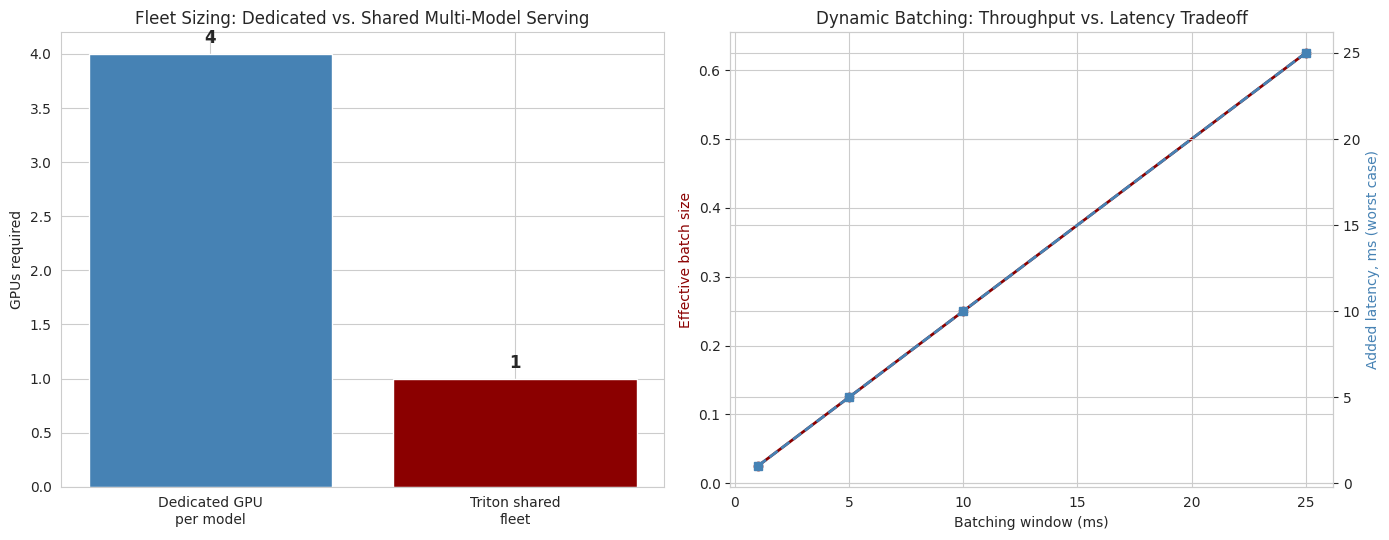

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(["Dedicated GPU\nper model", "Triton shared\nfleet"],
            [dedicated_gpus_needed, shared_gpus_needed], color=["steelblue", "darkred"])
for i, v in enumerate([dedicated_gpus_needed, shared_gpus_needed]):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("GPUs required")
axes[0].set_title("Fleet Sizing: Dedicated vs. Shared Multi-Model Serving")

ax2 = axes[1]
ax2.plot(batch_audit["batch_window_ms"], batch_audit["effective_batch_size"], marker="o",
         color="darkred", linewidth=2, label="Effective batch size")
ax2.set_xlabel("Batching window (ms)")
ax2.set_ylabel("Effective batch size", color="darkred")
ax2_twin = ax2.twinx()
ax2_twin.plot(batch_audit["batch_window_ms"], batch_audit["added_latency_ms_worst_case"], marker="s",
              color="steelblue", linewidth=2, linestyle="--", label="Added latency (worst case)")
ax2_twin.set_ylabel("Added latency, ms (worst case)", color="steelblue")
ax2.set_title("Dynamic Batching: Throughput vs. Latency Tradeoff")

plt.tight_layout()
plt.savefig("triton_multimodel_dashboard.png", dpi=120)
plt.show()

*(Insight: the GPU-count bar chart alone justifies the entire multi-model serving investment — the gap between dedicated and shared fleet sizing IS the ROI number a platform team puts in front of finance, distilled from every model's individually low, uncorrelated utilization.)*

## Real-World Use Case or Analogy

**The Hospital's Shared MRI Suite vs. One Machine Per Department.** If every hospital department (cardiology, oncology, orthopedics, neurology) insisted on its own dedicated MRI machine, most machines would sit idle most of the day — each department's actual scan volume rarely saturates a full-time machine (exactly the low dedicated-GPU-utilization numbers above). A modern hospital instead runs a **shared imaging suite**: one pool of MRI machines serving all departments, with a scheduling desk that batches compatible scan requests into efficient time blocks (dynamic batching) and runs urgent/routine scans on different machines concurrently based on capacity (instance groups). For a patient needing an MRI, then an immediate radiologist consult, then a specialist referral, a well-run hospital handles the whole chain *within one visit* rather than sending the patient to book each step separately across town (the ensemble-scheduler vs. client-orchestrated latency gap) — the coordination overhead saved is often larger than any single step's own speed. Triton is that shared imaging suite's scheduling desk, generalized to GPUs and ML models.